# Experiment 4.4 — Geometric vs. Robust, End to End

Notebook 4.1 measured a crossover in descriptor space: `Geometric` is more discriminative on
near-clean data, `Robust` from mild degradation on. This notebook checks whether the crossover
survives into ICP, using the configuration 4.2 and 4.3 settled on — hard matching, features
appended to positions, and `beta` annealed from a high start once the search has finished.

Both extractors run on identical observations at every noise level, with a fixed dropout, and
across neighbourhood sizes `k`: 4.1 found larger `k` more robust and more discriminative, at a
cost in runtime. Three quantities per configuration: **reliability** (fraction of seeds reaching
the global optimum), **accuracy** (median true residual among those seeds) and **runtime**.

In [1]:
import sys
sys.path.insert(0, '../src')

import time
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from tqdm import tqdm

from experiment_runner import fit_multi_seed
from feature_extractor import (
    FeatureExtractor,
    GeometricFeatureExtractor,
    RobustGeometricFeatureExtractor,
)
from icp import ICP, DeltaBetaAnnealing
from matcher import NearestNeighborMatcher
from synthetic import PointCloudObserver, SyntheticExperiment
from visualization import SweepVisualizer

plt.style.use('seaborn-v0_8-whitegrid')

N_SEEDS = 50
MAX_ITER, TOL = 400, 1e-6
GEN_KWARGS: dict[str, Any] = dict(n=500, t_scale=8.0, style='clustered')
K_VALUES = [20, 40, 80, 160]  # neighbourhood sizes
BETA_START = 8.0             # on 4.3's plateau: delta annealing reaches its best from here
DELTA_END_FRACTION = 0.05    # beta reaches 0 at 5% of the run's peak delta, as in 4.3

# Clouds are normalised to a point spacing of 1, so noise is in units of point spacing.
NOISE_LEVELS = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7]
DROPOUT_PROB = 0.1
# Dropout biases even a correct fit against the exact clouds, so success is judged at half a
# point spacing: far above that floor, far below the error of a wrong basin.
SUCCESS_TOL = 0.5 * SyntheticExperiment.generate(**GEN_KWARGS, seed=0).P.median_spacing

EXTRACTOR_FACTORIES: dict[str, type[FeatureExtractor]] = {
    'Geometric': GeometricFeatureExtractor,
    'Robust': RobustGeometricFeatureExtractor,
}
EXTRACTOR_COLORS = {'Geometric': 'tab:orange', 'Robust': 'tab:green'}

In [2]:
def build_icp(extractor: FeatureExtractor) -> ICP:
    """Hard-matching ICP with appended features and delta-annealed beta.

    Args:
        extractor: Feature extractor appended to positions.

    Returns:
        A configured ICP.
    """
    return ICP(
        matcher=NearestNeighborMatcher(feature_extractor=extractor, beta=BETA_START),
        max_iter=MAX_ITER, tol=TOL,
        callbacks=[DeltaBetaAnnealing(BETA_START, 0.0, end_fraction=DELTA_END_FRACTION)],
    )


def evaluate(extractor: FeatureExtractor, noise_std: float) -> tuple[float, float, float]:
    """Reliability, accuracy and runtime of one extractor at one noise level.

    A fresh observer per call replays the same degradation for every extractor, so the
    comparison is paired.

    Args:
        extractor: Feature extractor to evaluate.
        noise_std: Std of the Gaussian noise applied to each side independently.

    Returns:
        Tuple (fraction of seeds below SUCCESS_TOL, median true residual among them,
        median runtime per fit in seconds). The residual is NaN when no seed succeeded.
    """
    result = fit_multi_seed(
        build_icp(extractor), list(range(N_SEEDS)), experiment_kwargs=GEN_KWARGS,
        observer=PointCloudObserver(noise_std=noise_std, dropout_prob=DROPOUT_PROB),
        verbose=False,
    )
    residuals = np.array(result.mean_true_residuals)
    reached = residuals < SUCCESS_TOL
    accuracy = float(np.median(residuals[reached])) if reached.any() else float('nan')
    return float(reached.mean()), accuracy, float(np.median(result.durations_s))


# extractor -> (len(K_VALUES), len(NOISE_LEVELS), 3) of [reliability, accuracy, runtime]
scores = {
    name: np.array([
        [evaluate(factory(k=k), noise) for noise in NOISE_LEVELS]
        for k in tqdm(K_VALUES, desc=name)
    ])
    for name, factory in EXTRACTOR_FACTORIES.items()
}

Geometric:   0%|          | 0/4 [00:00<?, ?it/s]

Geometric:  25%|██▌       | 1/4 [00:19<00:58, 19.47s/it]

Geometric:  50%|█████     | 2/4 [00:40<00:41, 20.51s/it]

Geometric:  75%|███████▌  | 3/4 [01:16<00:27, 27.28s/it]

Geometric: 100%|██████████| 4/4 [01:55<00:00, 31.93s/it]

...

Robust:  25%|██▌       | 1/4 [00:16<00:48, 16.18s/it]

Robust:  50%|█████     | 2/4 [00:39<00:41, 20.59s/it]

Robust:  75%|███████▌  | 3/4 [01:20<00:29, 29.70s/it]

Robust: 100%|██████████| 4/4 [02:03<00:00, 35.17s/it]

Robust: 100%|██████████| 4/4 [02:03<00:00, 30.99s/it]

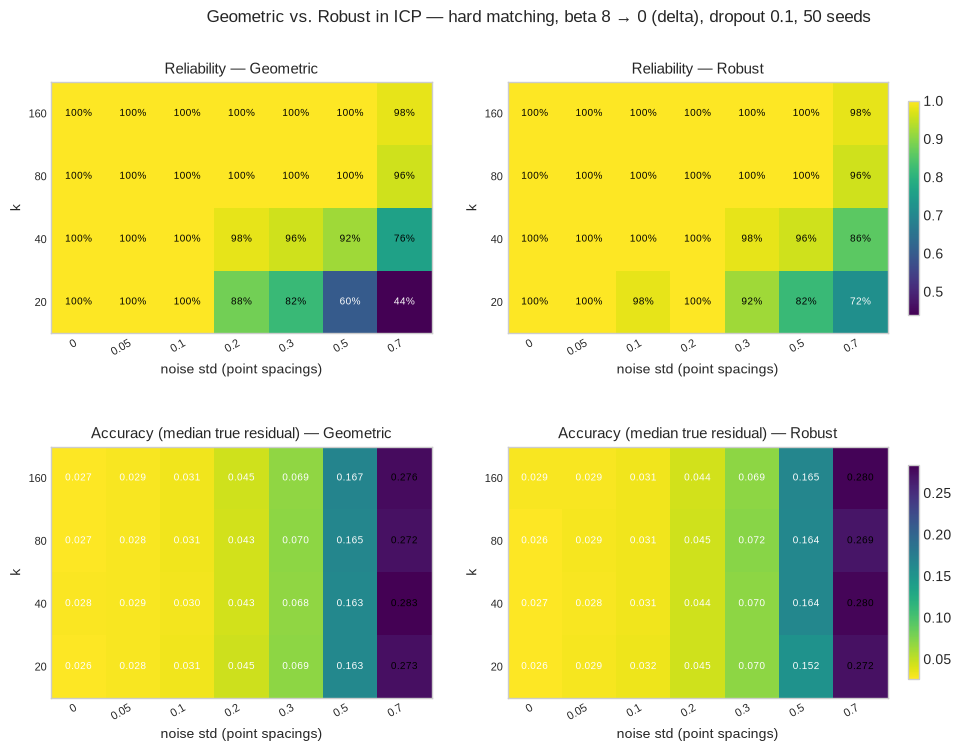

In [3]:
# Each row shares one colour scale across both extractors, so equal hues mean equal values.
fig, axes = plt.subplots(2, len(scores), figsize=(13, 8))
fig.subplots_adjust(hspace=0.45)
for row, (metric, fmt, cmap) in enumerate([('Reliability', '.0%', 'viridis'),
                                           ('Accuracy (median true residual)', '.3f', 'viridis_r')]):
    shared = np.concatenate([values[:, :, row].ravel() for values in scores.values()])
    for col, (name, values) in enumerate(scores.items()):
        image = SweepVisualizer.plot_heatmap(
            axes[row, col], values[:, :, row], x_labels=[f'{n:g}' for n in NOISE_LEVELS],
            y_labels=K_VALUES, x_label='noise std (point spacings)', y_label='k',
            title=f'{metric} — {name}', value_format=fmt, cmap=cmap,
            vmin=np.nanmin(shared), vmax=np.nanmax(shared),
        )
    fig.colorbar(image, ax=axes[row, :].tolist(), shrink=0.85, pad=0.02)
fig.suptitle(f'Geometric vs. Robust in ICP — hard matching, beta {BETA_START:g} → 0 (delta), '
             f'dropout {DROPOUT_PROB}, {N_SEEDS} seeds', y=0.97)
fig.savefig('../results/4_4_extractor_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

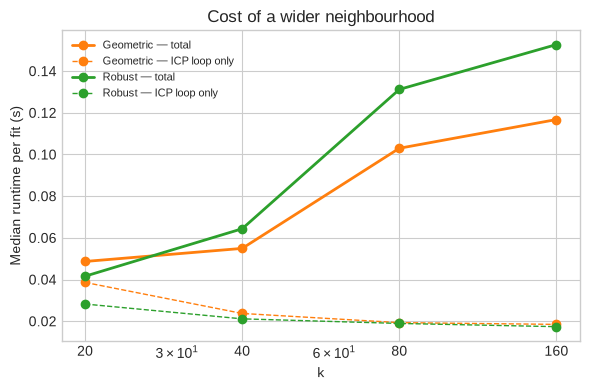

In [4]:
def extraction_time(extractor: FeatureExtractor, repeats: int = 5) -> float:
    """Median time to compute one cloud's descriptors.

    ``ICP.fit`` computes and caches both clouds' features before its timer starts, so
    ``durations_s`` covers the loop only; this is the cost it leaves out.

    Args:
        extractor: Feature extractor to time.
        repeats:   Number of timed calls.

    Returns:
        Seconds per call.
    """
    cloud = SyntheticExperiment.generate(**GEN_KWARGS, seed=0).P
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        extractor.get_features(cloud)
        times.append(time.perf_counter() - start)
    return float(np.median(times))


# Loop time barely depends on the noise level, so it is summarised over it.
fig, ax = plt.subplots(figsize=(6, 4))
for name, factory in EXTRACTOR_FACTORIES.items():
    loop = np.median(scores[name][:, :, 2], axis=1)
    extraction = np.array([2 * extraction_time(factory(k=k)) for k in K_VALUES])  # both clouds
    ax.plot(K_VALUES, loop + extraction, marker='o', linewidth=2,
            color=EXTRACTOR_COLORS[name], label=f'{name} — total')
    ax.plot(K_VALUES, loop, marker='o', linewidth=1, linestyle='--',
            color=EXTRACTOR_COLORS[name], label=f'{name} — ICP loop only')
ax.set(xscale='log', xticks=K_VALUES, xticklabels=K_VALUES, xlabel='k',
       ylabel='Median runtime per fit (s)', title='Cost of a wider neighbourhood')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig('../results/4_4_extractor_runtime.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- **`k` matters far more than the extractor.** With too small a neighbourhood, reliability
  drops under noise — sharply for `Geometric`, less for `Robust`. From `k=80` both recover
  essentially every seed up to half a point spacing of noise and behave identically.
  `Robust`'s advantage is tolerance of a too-small `k`, not a better descriptor at a good one.
- **Accuracy depends on neither.** Once `beta` has been annealed to 0, refinement uses
  positions alone, so the descriptor decides *whether* the basin is found, not how precisely
  the fit lands in it.
- **A wider neighbourhood costs extraction time, not ICP time.** The loop gets slightly
  shorter with `k` (the search finishes sooner), but descriptor extraction grows with `k` and
  dominates from `k=80`. `Robust`'s quantiles make it the more expensive extractor at every
  `k` above 20.
- No over-smoothing appears, even at `k=160`, a third of this cloud.

**Recommendation: `k=80`**, the smallest neighbourhood on the reliability plateau. At that
`k` the extractors are equally reliable and `Geometric` is cheaper; `Robust` is the safer
choice only where `k` has to stay small.